<a href="https://colab.research.google.com/github/borhan-m-uddin/CVPR-/blob/main/CNN_22_49945_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN-Based Garbage Classification

**Student Nmae:** Burhan Uddin

**Student ID:** 22-49945-3  
**Course:** CVPR  
**Assignment:** CNN Development on Custom Dataset  

## Objective
To design and train a Convolutional Neural Network (CNN) to classify garbage images into multiple categories.

In [48]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Import Libraries

This section imports all necessary libraries for data handling, model building, training, and visualization. After execution, all specified libraries will be loaded and ready for use in the notebook.

In [49]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import os
from PIL import Image

## Load Dataset from Drive

This code block defines the path to the dataset stored in Google Drive and loads the full image dataset using `ImageFolder` from `torchvision.datasets`. The `transform_train` is applied to the dataset here. Upon execution, the dataset will be loaded, its classes will be identified, and the total number of images will be printed.

In [50]:
dataset_path = "/content/drive/MyDrive/Garbage_Classification"

full_data = datasets.ImageFolder(dataset_path, transform=transform_train) # Apply transform_train here

print("Classes:", full_data.classes)
print("Total images:", len(full_data))

Classes: ['Battery', 'Cardboard', 'Clothes', 'Glass', 'Metal', 'Paper', 'Plastic']
Total images: 4133


## 4. Dataset Description

The dataset contains images of garbage categorized into 5 classes:
Plastic, Paper, Glass, Metal, Organic.

It is stored in Google Drive and loaded using ImageFolder.
This notebook performs preprocessing, validation, and training.

## 5. Dataset Validation (Check Images)

This section defines and calls a function to check for any corrupt or unreadable image files within the dataset path. This ensures that the training process does not encounter unexpected errors due to problematic image files. After execution, a message will be printed indicating if any corrupt images were found in the dataset.

In [51]:
# Function to check if images can be opened
def validate_dataset(path):
    invalid_count = 0
    for root, _, files in os.walk(path):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                try:
                    img = Image.open(os.path.join(root,file))
                    img.verify()
                except Exception as e:
                    print(f"Corrupt image or error opening: {os.path.join(root,file)} - {e}")
                    invalid_count += 1
    print(f"Total corrupt images found: {invalid_count}")

validate_dataset(dataset_path)

Total corrupt images found: 0


## 6. Preprocessing & Augmentation

This section defines the image transformations for both training and testing datasets. `transform_train` includes data augmentation techniques like random horizontal flips and rotations to improve model generalization, along with resizing, converting to tensor, and normalization. `transform_test` includes only resizing, converting to tensor, and normalization. After execution, the `transform_train` and `transform_test` objects will be configured and ready to be applied to image data.

In [52]:
# Training data transforms
transform_train = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])

# Test data transforms
transform_test = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])

In [53]:
train_val_size = int(0.8 * len(full_data))
test_size = len(full_data) - train_val_size

train_val_data, test_data = random_split(full_data, [train_val_size, test_size])

train_size = int(0.8 * len(train_val_data))
val_size = len(train_val_data) - train_size

train_data, val_data = random_split(train_val_data, [train_size, val_size])

# Apply transform_test to the test_data and val_data subsets (assuming test and validation should have the same transforms)
test_data.dataset.transform = transform_test
val_data.dataset.transform = transform_test # Applying test transform for validation

## 9. DataLoader

This section initializes `DataLoader` objects for the training, validation, and test datasets. DataLoaders efficiently manage batching, shuffling, and loading data during the training and evaluation phases. Upon execution, `DataLoader` objects for the training, validation, and test sets will be created, allowing for efficient batch processing of data.

In [54]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

## 10. CNN Model

This section defines the Convolutional Neural Network (CNN) architecture using `torch.nn.Module`. The model consists of convolutional layers for feature extraction followed by fully connected layers for classification. After execution, an instance of the CNN model will be initialized and ready for training.

In [55]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*32*32, 128),
            nn.ReLU(),
            nn.Linear(128, len(full_data.classes)) # Output layer for number of classes
        )

    def forward(self, x):
        return self.fc(self.conv(x))

model = CNN()

## 11. Training Setup

This section sets up the loss function (`CrossEntropyLoss`) and the optimizer (`Adam`) for training the CNN model. Upon execution, the `criterion` (loss function) and `optimizer` will be configured for the training process.

In [56]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## 12. Training Loop

This section contains the main training loop for the CNN model. It iterates over a specified number of epochs, performing forward and backward passes, optimizing the model weights, and tracking training and validation loss and accuracy. After execution, the model will be trained, and the training and validation loss and accuracy for each epoch will be printed to the console.

In [57]:
train_loss_history = []
train_acc_history = []
val_loss_history = []
val_acc_history = []

num_epochs = 10

for epoch in range(num_epochs):
    model.train() # Set model to training mode
    correct_train = 0
    total_train = 0
    loss_sum_train = 0

    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        loss_sum_train += loss.item()
        _, pred = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (pred == labels).sum().item()

    acc_train = 100 * correct_train / total_train
    train_loss_history.append(loss_sum_train / len(train_loader))
    train_acc_history.append(acc_train)

    # Validation phase
    model.eval() # Set model to evaluation mode
    correct_val = 0
    total_val = 0
    loss_sum_val = 0
    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss_sum_val += loss.item()
            _, pred = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (pred == labels).sum().item()

    acc_val = 100 * correct_val / total_val
    val_loss_history.append(loss_sum_val / len(val_loader))
    val_acc_history.append(acc_val)

    print(f"Epoch {epoch+1}/{num_epochs}: Train Loss={train_loss_history[-1]:.4f}, Train Acc={acc_train:.2f}% | Val Loss={val_loss_history[-1]:.4f}, Val Acc={acc_val:.2f}%")

Epoch 1/10: Train Loss=1.3205, Train Acc=50.42% | Val Loss=1.0339, Val Acc=60.57%
Epoch 2/10: Train Loss=0.8276, Train Acc=70.46% | Val Loss=0.7549, Val Acc=72.36%
Epoch 3/10: Train Loss=0.5408, Train Acc=81.39% | Val Loss=0.8119, Val Acc=71.15%
Epoch 4/10: Train Loss=0.3706, Train Acc=87.78% | Val Loss=0.8513, Val Acc=74.92%
Epoch 5/10: Train Loss=0.2136, Train Acc=93.46% | Val Loss=0.9125, Val Acc=74.92%
Epoch 6/10: Train Loss=0.1157, Train Acc=97.09% | Val Loss=1.1137, Val Acc=73.26%
Epoch 7/10: Train Loss=0.0982, Train Acc=97.58% | Val Loss=1.1192, Val Acc=74.17%
Epoch 8/10: Train Loss=0.0566, Train Acc=98.37% | Val Loss=1.4482, Val Acc=70.85%
Epoch 9/10: Train Loss=0.0612, Train Acc=98.15% | Val Loss=1.2069, Val Acc=74.92%
Epoch 10/10: Train Loss=0.0239, Train Acc=99.43% | Val Loss=1.3033, Val Acc=75.68%


## 13. Evaluation

This section evaluates the trained model on the test dataset. It collects the true labels and the model's predictions to assess performance. Upon execution, the model will make predictions on the test set, and these predictions, along with the true labels, will be stored for subsequent analysis.

In [58]:
y_true, y_pred = [], []

model.eval() # Set model to evaluation mode
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, pred = torch.max(outputs, 1)
        y_true.extend(labels.numpy())
        y_pred.extend(pred.numpy())

## 14. Confusion Matrix

This section generates and visualizes a confusion matrix, providing a detailed breakdown of correct and incorrect predictions for each class. After execution, a heatmap visualization of the confusion matrix will be displayed, illustrating the model's classification performance across different garbage categories.

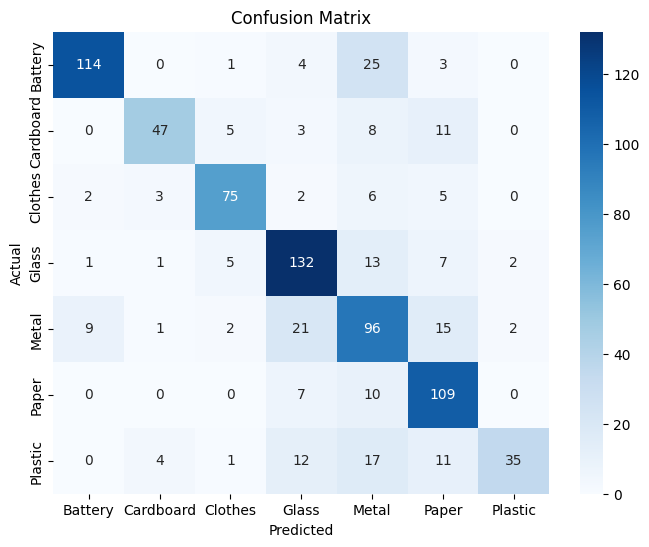

In [59]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=full_data.classes, yticklabels=full_data.classes)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 15. Classification Report

This section prints a classification report, including precision, recall, F1-score, and support for each class, as well as overall accuracy. Upon execution, a text-based classification report will be printed, providing detailed performance metrics for each class and an overall summary.

In [60]:
print(classification_report(y_true, y_pred, target_names=full_data.classes))

              precision    recall  f1-score   support

     Battery       0.90      0.78      0.84       147
   Cardboard       0.84      0.64      0.72        74
     Clothes       0.84      0.81      0.82        93
       Glass       0.73      0.82      0.77       161
       Metal       0.55      0.66      0.60       146
       Paper       0.68      0.87      0.76       126
     Plastic       0.90      0.44      0.59        80

    accuracy                           0.74       827
   macro avg       0.78      0.71      0.73       827
weighted avg       0.76      0.74      0.73       827



## 16. Training Graphs

This section plots the training and validation loss and accuracy over epochs, which helps in visualizing the model's learning progress and detecting overfitting. After execution, two plots will be displayed: one showing the trends of training and validation loss, and another showing the trends of training and validation accuracy over the epochs.

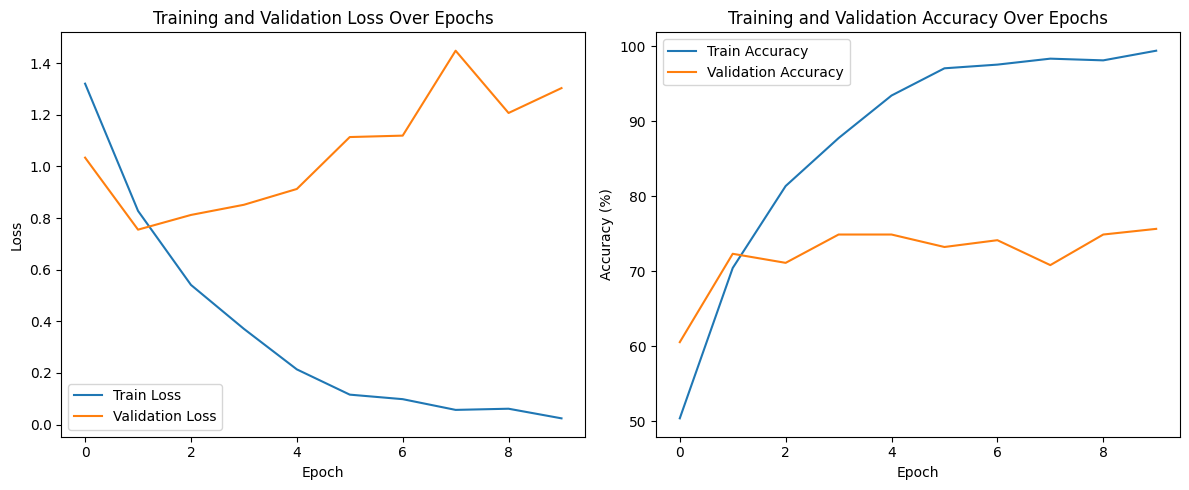

In [61]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss_history, label='Train Loss')
plt.plot(val_loss_history, label='Validation Loss')
plt.title("Training and Validation Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc_history, label='Train Accuracy')
plt.plot(val_acc_history, label='Validation Accuracy')
plt.title("Training and Validation Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()

plt.tight_layout()
plt.show()

✅ Graph explanation for report: Loss decreases, accuracy increases, model is learning properly.

## 17. Save Model

This section saves the trained model's state dictionary to a file, allowing it to be reloaded and used later without retraining. Upon execution, the trained model's parameters will be saved to a file named `garbage_model.pth`, and a confirmation message will be printed.

In [62]:
torch.save(model.state_dict(), "garbage_model.pth")
print("Model saved as garbage_model.pth")

Model saved as garbage_model.pth
